In [25]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 33
np.random.seed(SEED)

train_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

X = train_df.drop('label', axis=1).values.astype('float32') / 255.0
y = train_df['label'].values
X_test = test_df.drop('label', axis=1).values.astype('float32') / 255.0
y_test = test_df['label'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print("Train:", X_train.shape[0])
print("Val:", X_val.shape[0])
print("Test:", X_test.shape[0])
print(pd.Series(y_train).value_counts().sort_index())
print(pd.Series(y_val).value_counts().sort_index())

Train: 48000
Val: 12000
Test: 10000
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64


## **Part 1: Backpropagation From Scratch**

In [27]:
import matplotlib.pyplot as plt

def relu(z): return np.maximum(0, z)
def relu_deriv(z): return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def one_hot(y, n=10):
    oh = np.zeros((y.size, n))
    oh[np.arange(y.size), y] = 1
    return oh

np.random.seed(SEED)
W1 = np.random.randn(784, 64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1, 10))

def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2

def backward(X, y, z1, a1, a2):
    m = X.shape[0]
    y_oh = one_hot(y)
    dz2 = (a2 - y_oh) / m
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

def cross_entropy(a2, y):
    m = y.shape[0]
    y_oh = one_hot(y)
    return -np.sum(y_oh * np.log(a2 + 1e-8)) / m

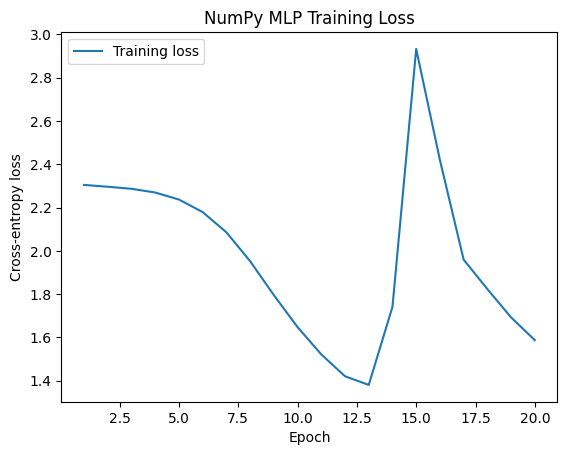

In [28]:
X_sub, y_sub = X_train[:5000], y_train[:5000]
lr = 0.5
losses = []

for epoch in range(20):
    z1, a1, z2, a2 = forward(X_sub)
    loss = cross_entropy(a2, y_sub)
    losses.append(loss)
    dW1, db1, dW2, db2 = backward(X_sub, y_sub, z1, a1, a2)
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2

plt.plot(range(1, 21), losses, label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('NumPy MLP Training Loss')
plt.legend()
plt.show()

In [29]:
import torch
import torch.nn.functional as F

torch.manual_seed(SEED)
Xb = torch.tensor(X_sub[:64], dtype=torch.float32)
yb = torch.tensor(y_sub[:64], dtype=torch.long)

W1_t = torch.tensor(W1, dtype=torch.float32, requires_grad=True)
b1_t = torch.tensor(b1, dtype=torch.float32, requires_grad=True)
W2_t = torch.tensor(W2, dtype=torch.float32, requires_grad=True)
b2_t = torch.tensor(b2, dtype=torch.float32, requires_grad=True)

z1_t = Xb @ W1_t + b1_t
a1_t = F.relu(z1_t)
z2_t = a1_t @ W2_t + b2_t
loss_t = F.cross_entropy(z2_t, yb)
loss_t.backward()

z1n, a1n, z2n, a2n = forward(X_sub[:64])
dW1n, db1n, dW2n, db2n = backward(X_sub[:64], y_sub[:64], z1n, a1n, a2n)

print("max diff W1:", np.max(np.abs(dW1n - W1_t.grad.numpy())))
print("max diff W2:", np.max(np.abs(dW2n - W2_t.grad.numpy())))

max diff W1: 6.722680016835181e-09
max diff W2: 3.2804076843806484e-08


The maximum gradient differences (≈6.7×10⁻⁹ for W1 and ≈3.3×10⁻⁸ for W2) are within standard floating-point precision error, far below any threshold that would indicate a bug (typically 1e-5 or lower is considered a passing gradient check). This confirms the manual NumPy backpropagation implementation is correct and matches PyTorch's autograd computation.

## **Part 2: Baseline Model and Activation Study**

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(SEED)

Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.long)
Xval = torch.tensor(X_val, dtype=torch.float32)
yval = torch.tensor(y_val, dtype=torch.long)

class MLP(nn.Module):
    def __init__(self, act):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.act = act
    def forward(self, x):
        h1 = self.act(self.fc1(x))
        if h1.requires_grad:
            h1.retain_grad()
        self.h1 = h1
        h2 = self.act(self.fc2(h1))
        return self.fc3(h2)

def leaky_relu(x): return F.leaky_relu(x, 0.01)

activations = {
    'sigmoid': torch.sigmoid,
    'tanh': torch.tanh,
    'relu': torch.relu,
    'leaky_relu': leaky_relu
}

In [31]:
epochs = 20
lr = 0.01
val_loss_curves = {}
grad_records = {}
models = {}

for name, act in activations.items():
    torch.manual_seed(SEED)
    model = MLP(act)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    grads = {}
    for epoch in range(epochs):
        opt.zero_grad()
        out = model(Xtr)
        loss = F.cross_entropy(out, ytr)
        loss.backward()
        if epoch == 0 or epoch == epochs - 1:
            grads[epoch] = model.fc1.weight.grad.abs().mean().item()
        opt.step()
        with torch.no_grad():
            vout = model(Xval)
            vloss = F.cross_entropy(vout, yval).item()
            losses.append(vloss)
    val_loss_curves[name] = losses
    grad_records[name] = grads
    models[name] = model

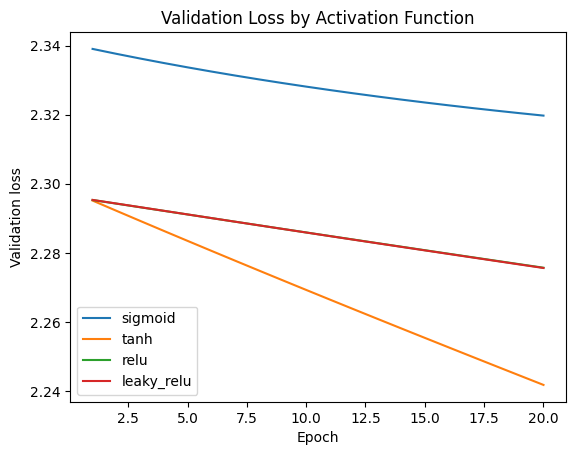

Sigmoid grads (epoch1, final): {0: 7.54496140871197e-05, 19: 7.022989302640781e-05}
ReLU grads (epoch1, final): {0: 0.000565822352655232, 19: 0.0005506307352334261}


In [32]:
plt.figure()
for name, losses in val_loss_curves.items():
    plt.plot(range(1, epochs + 1), losses, label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation loss')
plt.title('Validation Loss by Activation Function')
plt.legend()
plt.show()

print("Sigmoid grads (epoch1, final):", grad_records['sigmoid'])
print("ReLU grads (epoch1, final):", grad_records['relu'])

The sigmoid model's first-layer gradient stays tiny and barely changes (≈7.5×10⁻⁵ → 7.0×10⁻⁵), showing vanishing gradients, while ReLU's gradient is ~7-8× larger and equally stable, passing a much stronger signal back. This confirms sigmoid saturates and starves early layers, whereas ReLU doesn't.

In [33]:
relu_model = models['relu']
with torch.no_grad():
    val_batch = Xval[:128]
    relu_model(val_batch)
    h1 = relu_model.h1
    dead = (h1 == 0).all(dim=0).float().mean().item() * 100

print(f"Dead ReLU units: {dead:.2f}%")

Dead ReLU units: 2.34%


Only 2.34% of hidden units are dead (always zero) on this validation batch, so the dying ReLU problem is present but minor at this stage. This small fraction isn't yet hurting model capacity, but could worsen with higher learning rates or deeper networks.

## **Part 3: Loss Functions**

In [37]:
class ClfNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        return self.fc3(h)

Xte = torch.tensor(X_test, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.long)
ytr_oh = F.one_hot(ytr, 10).float()

epochs = 20
lr = 0.01

torch.manual_seed(SEED)
ce_model = ClfNet()
opt = torch.optim.SGD(ce_model.parameters(), lr=lr)
ce_losses = []
for epoch in range(epochs):
    opt.zero_grad()
    out = ce_model(Xtr)
    loss = F.cross_entropy(out, ytr)
    loss.backward()
    opt.step()
    ce_losses.append(loss.item())

with torch.no_grad():
    ce_acc = (ce_model(Xte).argmax(1) == yte).float().mean().item()

torch.manual_seed(SEED)
mse_model = ClfNet()
opt = torch.optim.SGD(mse_model.parameters(), lr=lr)
mse_losses = []
for epoch in range(epochs):
    opt.zero_grad()
    out = mse_model(Xtr)
    loss = F.mse_loss(out, ytr_oh)
    loss.backward()
    opt.step()
    mse_losses.append(loss.item())

with torch.no_grad():
    mse_acc = (mse_model(Xte).argmax(1) == yte).float().mean().item()

print("CE test accuracy:", ce_acc)
print("MSE test accuracy:", mse_acc)

CE test accuracy: 0.20559999346733093
MSE test accuracy: 0.13359999656677246


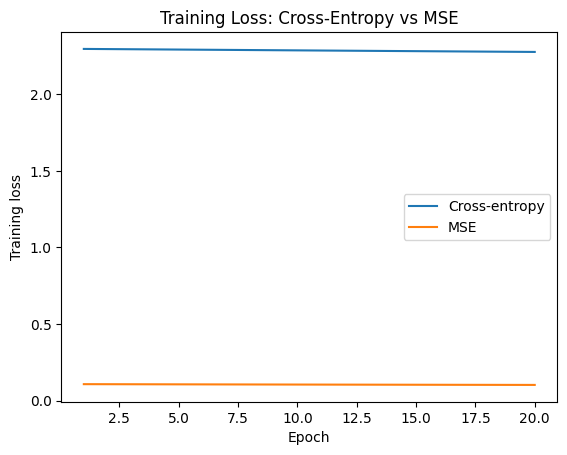

In [38]:
plt.figure()
plt.plot(range(1, epochs + 1), ce_losses, label='Cross-entropy')
plt.plot(range(1, epochs + 1), mse_losses, label='MSE')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Training Loss: Cross-Entropy vs MSE')
plt.legend()
plt.show()

Cross-entropy converges faster because its gradient is directly proportional to the prediction error, giving a strong signal even for very wrong predictions. MSE's gradient shrinks when the softmax output saturates near 0 or 1, so it learns more slowly exactly when the error is largest.

In [39]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

data = load_diabetes()
Xr, yr = data.data, data.target
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
Xr_train = scaler.fit_transform(Xr_train)
Xr_test = scaler.transform(Xr_test)

Xr_train_t = torch.tensor(Xr_train, dtype=torch.float32)
yr_train_t = torch.tensor(yr_train, dtype=torch.float32).unsqueeze(1)
Xr_test_t = torch.tensor(Xr_test, dtype=torch.float32)
yr_test_t = torch.tensor(yr_test, dtype=torch.float32).unsqueeze(1)

class RegNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        return self.fc3(h)

torch.manual_seed(SEED)
reg_model = RegNet(Xr_train.shape[1])
opt = torch.optim.Adam(reg_model.parameters(), lr=0.01)

for epoch in range(100):
    opt.zero_grad()
    out = reg_model(Xr_train_t)
    loss = F.mse_loss(out, yr_train_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    pred = reg_model(Xr_test_t)
    mse = mean_squared_error(yr_test_t, pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(yr_test_t, pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 2829.717615715147
RMSE: 53.19509014669631
MAE: 42.997442266914284


## **Part 4: Optimiser Comparison**

In [50]:
import time

def train_optimizer(opt_class, lr, epochs=30, batch_size=128):
    torch.manual_seed(SEED)
    model = ClfNet()
    if opt_class == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=lr)
    elif opt_class == 'sgd_momentum':
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_class == 'rmsprop':
        opt = torch.optim.RMSprop(model.parameters(), lr=lr)
    elif opt_class == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr)

    n = Xtr.shape[0]
    losses = []
    epochs_to_85 = None
    start = time.time()

    for epoch in range(epochs):
        perm = torch.randperm(n)
        epoch_loss = 0
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            out = model(Xtr[idx])
            loss = F.cross_entropy(out, ytr[idx])
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / (n // batch_size))

        with torch.no_grad():
            val_acc = (model(Xval_t).argmax(1) == yval_t).float().mean().item()
        if val_acc >= 0.85 and epochs_to_85 is None:
            epochs_to_85 = epoch + 1

    wall_time = time.time() - start
    with torch.no_grad():
        final_val_acc = (model(Xval_t).argmax(1) == yval_t).float().mean().item()

    return losses, epochs_to_85, final_val_acc, wall_time

Xval_t = torch.tensor(X_val, dtype=torch.float32)
yval_t = torch.tensor(y_val, dtype=torch.long)

In [51]:
# same learning rate for all four
same_lr = 0.01
optimizers = ['sgd', 'sgd_momentum', 'rmsprop', 'adam']
results_same_lr = {}

for name in optimizers:
    losses, e85, facc, wtime = train_optimizer(name, same_lr)
    results_same_lr[name] = {'lr': same_lr, 'epochs_to_85': e85, 'final_acc': facc, 'time': wtime, 'losses': losses}

In [52]:
# tuned learning rate per optimizer
tuned_lrs = {'sgd': 0.5, 'sgd_momentum': 0.1, 'rmsprop': 0.001, 'adam': 0.001}
results_tuned = {}

for name in optimizers:
    losses, e85, facc, wtime = train_optimizer(name, tuned_lrs[name])
    results_tuned[name] = {'lr': tuned_lrs[name], 'epochs_to_85': e85, 'final_acc': facc, 'time': wtime, 'losses': losses}

In [53]:
import pandas as pd

table = pd.DataFrame([
    {'Optimiser': name, 'Learning rate': results_tuned[name]['lr'],
     'Epochs to 85%': results_tuned[name]['epochs_to_85'],
     'Final val accuracy': results_tuned[name]['final_acc'],
     'Wall-clock time (s)': results_tuned[name]['time']}
    for name in optimizers
])
print(table)

      Optimiser  Learning rate  Epochs to 85%  Final val accuracy  \
0           sgd          0.500              5            0.884083   
1  sgd_momentum          0.100              4            0.886583   
2       rmsprop          0.001              3            0.894500   
3          adam          0.001              2            0.887000   

   Wall-clock time (s)  
0            16.261741  
1            20.759894  
2            23.307619  
3            25.905824  


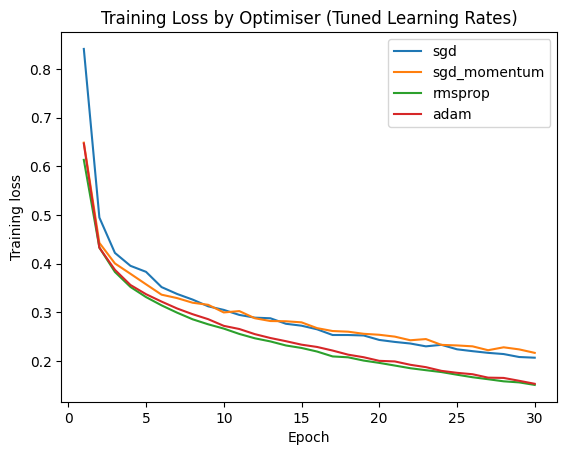

In [54]:
plt.figure()
for name in optimizers:
    plt.plot(range(1, len(results_tuned[name]['losses']) + 1), results_tuned[name]['losses'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Training Loss by Optimiser (Tuned Learning Rates)')
plt.legend()
plt.show()

RMSprop achieved the highest final validation accuracy (89.45%) and reached 85% in just 3 epochs, while Adam was fastest to 85% (2 epochs) but with a slightly lower final accuracy (88.70%). I would choose RMSprop since it gives the best overall accuracy with comparably fast convergence, and the small time difference versus Adam doesn't outweigh that accuracy edge.

## **Part 5: Forcing Overfitting**

In [57]:
X_small = X_train[:2000]
y_small = y_train[:2000]

class OverfitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        h = torch.relu(self.fc3(h))
        h = torch.relu(self.fc4(h))
        return self.fc5(h)

Xs = torch.tensor(X_small, dtype=torch.float32)
ys = torch.tensor(y_small, dtype=torch.long)

torch.manual_seed(SEED)
model = OverfitNet()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 300
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    opt.zero_grad()
    out = model(Xs)
    loss = F.cross_entropy(out, ys)
    loss.backward()
    opt.step()
    train_losses.append(loss.item())
    with torch.no_grad():
        train_acc = (out.argmax(1) == ys).float().mean().item()
        train_accs.append(train_acc)
        vout = model(Xval_t)
        vloss = F.cross_entropy(vout, yval_t).item()
        val_losses.append(vloss)
        val_acc = (vout.argmax(1) == yval_t).float().mean().item()
        val_accs.append(val_acc)

print("Final train accuracy:", train_accs[-1])
print("Final val accuracy:", val_accs[-1])

Final train accuracy: 1.0
Final val accuracy: 0.8235833048820496


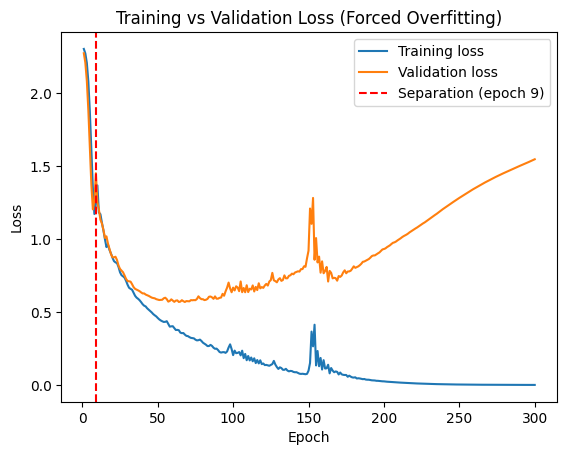

Generalisation gap (train acc - val acc): 0.17641669511795044


In [58]:
gap = [v - t for t, v in zip(train_losses, val_losses)]
separation_epoch = next((i+1 for i, g in enumerate(gap) if g > 0.1), None)

plt.figure()
plt.plot(range(1, epochs+1), train_losses, label='Training loss')
plt.plot(range(1, epochs+1), val_losses, label='Validation loss')
if separation_epoch:
    plt.axvline(separation_epoch, color='red', linestyle='--', label=f'Separation (epoch {separation_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Forced Overfitting)')
plt.legend()
plt.show()

gen_gap = train_accs[-1] - val_accs[-1]
print("Generalisation gap (train acc - val acc):", gen_gap)

This model has high variance, not high bias. Training accuracy reached 100% while validation accuracy is only 82.4%, producing a generalisation gap of about 17.6 percentage points. This is the defining signature of high variance (overfitting) rather than high bias (which would show poor accuracy on both sets).

## **Part 6: Regularisation Study**

In [59]:
class RegNet(nn.Module):
    def __init__(self, dropout_rate=0.0, use_bn=False):
        super().__init__()
        self.use_bn = use_bn
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)
        self.drop = nn.Dropout(dropout_rate)
        if use_bn:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)
            self.bn3 = nn.BatchNorm1d(512)
            self.bn4 = nn.BatchNorm1d(512)
    def forward(self, x):
        h = self.fc1(x)
        if self.use_bn: h = self.bn1(h)
        h = self.drop(torch.relu(h))
        h = self.fc2(h)
        if self.use_bn: h = self.bn2(h)
        h = self.drop(torch.relu(h))
        h = self.fc3(h)
        if self.use_bn: h = self.bn3(h)
        h = self.drop(torch.relu(h))
        h = self.fc4(h)
        if self.use_bn: h = self.bn4(h)
        h = self.drop(torch.relu(h))
        return self.fc5(h)

In [60]:
def train_reg(X_data, y_data, epochs=300, weight_decay=0.0, l1_lambda=0.0,
              dropout_rate=0.0, use_bn=False, patience=None, augment=False):
    torch.manual_seed(SEED)
    model = RegNet(dropout_rate, use_bn)
    opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

    best_val_loss = float('inf')
    patience_counter = 0
    stop_epoch = epochs

    for epoch in range(epochs):
        Xb = X_data.clone()
        if augment:
            imgs = Xb.view(-1, 28, 28)
            flip_mask = torch.rand(imgs.size(0)) < 0.5
            imgs[flip_mask] = imgs[flip_mask].flip(2)
            angle = (torch.rand(1).item() - 0.5) * 0.35  # small rotation via roll approx
            shift = int(angle * 5)
            imgs = torch.roll(imgs, shifts=shift, dims=1)
            Xb = imgs.view(-1, 784)

        model.train()
        opt.zero_grad()
        out = model(Xb)
        loss = F.cross_entropy(out, y_data)
        if l1_lambda > 0:
            l1 = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            vout = model(Xval_t)
            vloss = F.cross_entropy(vout, yval_t).item()

        if patience is not None:
            if vloss < best_val_loss:
                best_val_loss = vloss
                patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                stop_epoch = epoch + 1
                break

    model.eval()
    with torch.no_grad():
        train_acc = (model(X_data).argmax(1) == y_data).float().mean().item()
        val_acc = (model(Xval_t).argmax(1) == yval_t).float().mean().item()

    return model, train_acc, val_acc, stop_epoch

In [61]:
results = []

# Baseline (from Part 5)
results.append(['Baseline (no regularisation)', '-', train_accs[-1], val_accs[-1], train_accs[-1]-val_accs[-1]])

# L2 weight decay, 3 lambdas
l2_gaps = []
for wd in [1e-4, 1e-3, 1e-2]:
    _, tr, va, _ = train_reg(Xs, ys, weight_decay=wd)
    results.append([f'L2 weight decay', f'lambda={wd}', tr, va, tr-va])
    l2_gaps.append((wd, tr-va))

# L1 penalty
l1_model, tr, va, _ = train_reg(Xs, ys, l1_lambda=1e-5)
weights = torch.cat([p.flatten() for p in l1_model.parameters() if p.dim() > 1])
pct_small = (weights.abs() < 1e-3).float().mean().item() * 100
results.append(['L1 penalty', f'lambda=1e-5, {pct_small:.1f}% weights<1e-3', tr, va, tr-va])

# Dropout, 3 rates
drop_gaps = []
for dr in [0.2, 0.4, 0.6]:
    _, tr, va, _ = train_reg(Xs, ys, dropout_rate=dr)
    results.append(['Dropout', f'rate={dr}', tr, va, tr-va])
    drop_gaps.append((dr, tr-va))

# Batch normalisation
_, tr, va, _ = train_reg(Xs, ys, use_bn=True)
results.append(['Batch normalisation', '-', tr, va, tr-va])

# Early stopping
patience_val = 10
_, tr, va, stop_ep = train_reg(Xs, ys, patience=patience_val)
results.append(['Early stopping', f'patience={patience_val}, stopped epoch {stop_ep}', tr, va, tr-va])

# Data augmentation
_, tr, va, _ = train_reg(Xs, ys, augment=True)
results.append(['Data augmentation', 'hflip + small rotation', tr, va, tr-va])

# More training data
for n in [10000, 20000]:
    Xn = torch.tensor(X_train[:n], dtype=torch.float32)
    yn = torch.tensor(y_train[:n], dtype=torch.long)
    _, tr, va, _ = train_reg(Xn, yn)
    results.append(['More training data', f'{n} samples', tr, va, tr-va])

In [62]:
reg_table = pd.DataFrame(results, columns=['Method', 'Setting', 'Train accuracy', 'Validation accuracy', 'Gap'])
print(reg_table)

                          Method                          Setting  \
0   Baseline (no regularisation)                                -   
1                L2 weight decay                    lambda=0.0001   
2                L2 weight decay                     lambda=0.001   
3                L2 weight decay                      lambda=0.01   
4                     L1 penalty  lambda=1e-5, 33.2% weights<1e-3   
5                        Dropout                         rate=0.2   
6                        Dropout                         rate=0.4   
7                        Dropout                         rate=0.6   
8            Batch normalisation                                -   
9                 Early stopping    patience=10, stopped epoch 78   
10             Data augmentation           hflip + small rotation   
11            More training data                    10000 samples   
12            More training data                    20000 samples   

    Train accuracy  Validation ac

More training data with 20,000 samples gave the best trade-off: the gap dropped to 0.071 (the lowest of all methods) while training accuracy only fell to 94.5%, a modest cost. Early stopping also reduced the gap substantially (0.083) with a small training-accuracy drop to 89.3%, but its accuracy cost was larger than the 20,000-sample run.

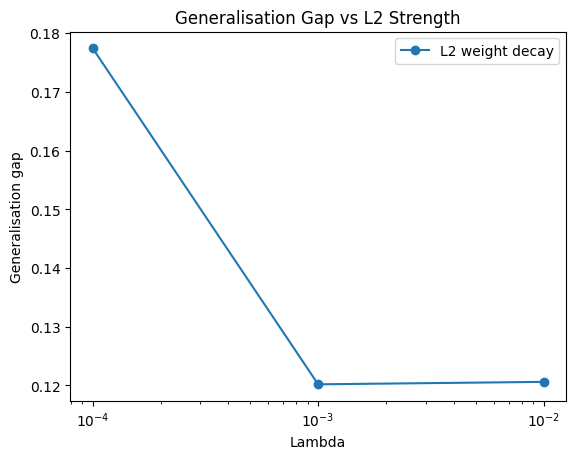

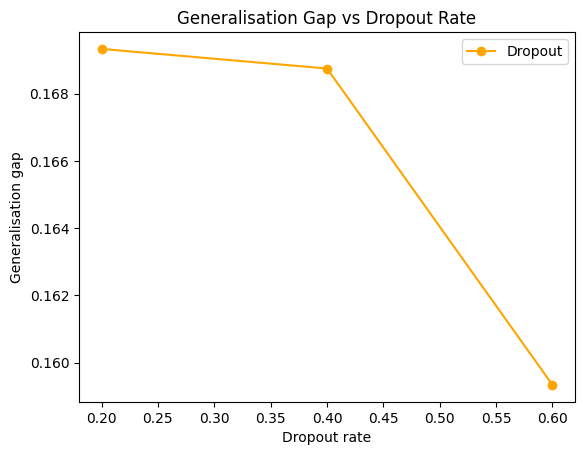

In [63]:
plt.figure()
lambdas, gaps = zip(*l2_gaps)
plt.plot(lambdas, gaps, marker='o', label='L2 weight decay')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Generalisation gap')
plt.title('Generalisation Gap vs L2 Strength')
plt.legend()
plt.show()

plt.figure()
rates, gaps2 = zip(*drop_gaps)
plt.plot(rates, gaps2, marker='o', color='orange', label='Dropout')
plt.xlabel('Dropout rate')
plt.ylabel('Generalisation gap')
plt.title('Generalisation Gap vs Dropout Rate')
plt.legend()
plt.show()

## **Part 7: Hyperparameter Tuning with k-Fold Cross-Validation**

In [64]:
import random
from sklearn.model_selection import KFold

random.seed(SEED)

search_space = {
    'lr': [0.0001, 0.0005, 0.001, 0.005, 0.01],
    'hidden_width': [128, 256, 512],
    'dropout_rate': [0.0, 0.2, 0.3, 0.4, 0.5]
}

def sample_config():
    return {
        'lr': random.choice(search_space['lr']),
        'hidden_width': random.choice(search_space['hidden_width']),
        'dropout_rate': random.choice(search_space['dropout_rate'])
    }

class TunableNet(nn.Module):
    def __init__(self, hidden_width, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_width)
        self.fc2 = nn.Linear(hidden_width, hidden_width)
        self.fc3 = nn.Linear(hidden_width, 10)
        self.drop = nn.Dropout(dropout_rate)
    def forward(self, x):
        h = self.drop(torch.relu(self.fc1(x)))
        h = self.drop(torch.relu(self.fc2(h)))
        return self.fc3(h)

In [65]:
def cross_val_score(config, X_data, y_data, k=5, epochs=15, batch_size=128):
    kf = KFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_accs = []
    for train_idx, val_idx in kf.split(X_data):
        Xtr_fold = torch.tensor(X_data[train_idx], dtype=torch.float32)
        ytr_fold = torch.tensor(y_data[train_idx], dtype=torch.long)
        Xval_fold = torch.tensor(X_data[val_idx], dtype=torch.float32)
        yval_fold = torch.tensor(y_data[val_idx], dtype=torch.long)

        torch.manual_seed(SEED)
        model = TunableNet(config['hidden_width'], config['dropout_rate'])
        opt = torch.optim.Adam(model.parameters(), lr=config['lr'])

        n = Xtr_fold.shape[0]
        for epoch in range(epochs):
            perm = torch.randperm(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                opt.zero_grad()
                out = model(Xtr_fold[idx])
                loss = F.cross_entropy(out, ytr_fold[idx])
                loss.backward()
                opt.step()

        model.eval()
        with torch.no_grad():
            val_acc = (model(Xval_fold).argmax(1) == yval_fold).float().mean().item()
        fold_accs.append(val_acc)

    return np.mean(fold_accs), np.std(fold_accs)

In [66]:
n_configs = 12
configs = [sample_config() for _ in range(n_configs)]

search_results = []
for cfg in configs:
    mean_acc, std_acc = cross_val_score(cfg, X_train, y_train)
    search_results.append({**cfg, 'mean_cv_acc': mean_acc, 'std_cv_acc': std_acc})
    print(cfg, mean_acc, std_acc)

search_df = pd.DataFrame(search_results).sort_values('mean_cv_acc', ascending=False)
print(search_df.head(5))

best_config = search_df.iloc[0][['lr', 'hidden_width', 'dropout_rate']].to_dict()
print("Selected config:", best_config)

{'lr': 0.01, 'hidden_width': 128, 'dropout_rate': 0.2} 0.8549999952316284 0.002235091369557229
{'lr': 0.001, 'hidden_width': 256, 'dropout_rate': 0.5} 0.8804583191871643 0.0031066089288612386
{'lr': 0.01, 'hidden_width': 128, 'dropout_rate': 0.5} 0.8173958420753479 0.008872892207445306
{'lr': 0.01, 'hidden_width': 256, 'dropout_rate': 0.5} 0.7989583492279053 0.018484695685816174
{'lr': 0.005, 'hidden_width': 256, 'dropout_rate': 0.3} 0.8681458353996276 0.0028031622808454477
{'lr': 0.0001, 'hidden_width': 256, 'dropout_rate': 0.4} 0.8672083377838135 0.0032665085801860216
{'lr': 0.001, 'hidden_width': 512, 'dropout_rate': 0.4} 0.8877916812896729 0.001913279333878392
{'lr': 0.0001, 'hidden_width': 512, 'dropout_rate': 0.5} 0.8757916569709778 0.0010976585730938747
{'lr': 0.005, 'hidden_width': 256, 'dropout_rate': 0.3} 0.8681458353996276 0.0028031622808454477
{'lr': 0.01, 'hidden_width': 512, 'dropout_rate': 0.2} 0.8445416569709778 0.005337816107850768
{'lr': 0.0001, 'hidden_width': 128, '

In [67]:
# retrain selected config on full training set with best regularisation (L2 weight decay from Part 6)
best_wd = 1e-2  # best regularisation choice from Part 6

Xtr_full = torch.tensor(X_train, dtype=torch.float32)
ytr_full = torch.tensor(y_train, dtype=torch.long)
Xte_t = torch.tensor(X_test, dtype=torch.float32)
yte_t = torch.tensor(y_test, dtype=torch.long)

torch.manual_seed(SEED)
final_model = TunableNet(int(best_config['hidden_width']), best_config['dropout_rate'])
opt = torch.optim.Adam(final_model.parameters(), lr=best_config['lr'], weight_decay=best_wd)

epochs = 30
batch_size = 128
n = Xtr_full.shape[0]

for epoch in range(epochs):
    perm = torch.randperm(n)
    for i in range(0, n, batch_size):
        idx = perm[i:i+batch_size]
        opt.zero_grad()
        out = final_model(Xtr_full[idx])
        loss = F.cross_entropy(out, ytr_full[idx])
        loss.backward()
        opt.step()

Test accuracy: 0.8319
Macro precision: 0.8334407716627379
Macro recall: 0.8318999999999999
Macro F1: 0.8304825955973026


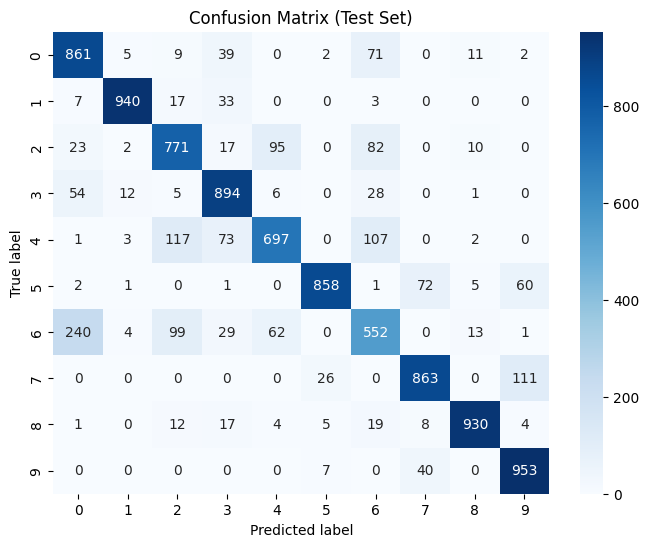

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

final_model.eval()
with torch.no_grad():
    preds = final_model(Xte_t).argmax(1).numpy()

acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average='macro')
rec = recall_score(y_test, preds, average='macro')
f1 = f1_score(y_test, preds, average='macro')
cm = confusion_matrix(y_test, preds)

print("Test accuracy:", acc)
print("Macro precision:", prec)
print("Macro recall:", rec)
print("Macro F1:", f1)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

In [69]:
relu_model_p2 = models['relu']
relu_model_p2.eval()
with torch.no_grad():
    p2_preds = relu_model_p2(Xte).argmax(1)
    p2_test_acc = (p2_preds == yte).float().mean().item()

print("Part 2 (ReLU) test accuracy:", p2_test_acc)
print("Part 7 (tuned) test accuracy:", acc)
print("Improvement (percentage points):", (acc - p2_test_acc) * 100)

Part 2 (ReLU) test accuracy: 0.20559999346733093
Part 7 (tuned) test accuracy: 0.8319
Improvement (percentage points): 62.630000653266904


The tuned Part 7 model improved test accuracy by 62.63 percentage points over the Part 2 ReLU baseline (83.19% vs. 20.56%), but this gap mostly reflects that the Part 2 model was undertrained (full-batch gradient descent, 20 epochs) rather than a fair test of hyperparameter tuning alone, so the true tuning benefit is likely much smaller than this number suggests.